In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [10]:
import pandas as pd

data = pd.read_csv("Fake.csv")
data = pd.read_csv("True.csv")

data.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [11]:
data.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
data.shape

(21417, 4)

In [13]:
data.columns

Index(['title', 'text', 'subject', 'date'], dtype='str')

In [14]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [15]:
data = data.dropna()

In [16]:
X = data['text']

In [17]:
data.columns

Index(['title', 'text', 'subject', 'date'], dtype='str')

In [18]:
data.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [20]:
data.columns

Index(['title', 'text', 'subject', 'date'], dtype='str')

In [22]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Fake.csv',
 'Fake_News_Detection.ipynb.ipynb',
 'True.csv']

In [23]:
import pandas as pd

fake = pd.read_csv("Fake.csv")

real = pd.read_csv("True.csv")

In [24]:
fake['label'] = 0

real['label'] = 1

In [25]:
data = pd.concat([fake, real])

In [26]:
data.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

In [27]:
X = data['text']

y = data['label']

In [28]:
import re

def clean_text(text):

    text = re.sub('[^a-zA-Z]', ' ', text)

    text = text.lower()

    return text

In [30]:
X = X.apply(clean_text)

In [31]:
X.head()

0    donald trump just couldn t wish all americans ...
1    house intelligence committee chairman devin nu...
2    on friday  it was revealed that former milwauk...
3    on christmas day  donald trump announced that ...
4    pope francis used his annual christmas day mes...
Name: text, dtype: str

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
tfidf = TfidfVectorizer(max_features=5000)

In [34]:
X = tfidf.fit_transform(X)

In [35]:
X.shape

(44898, 5000)

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
X_train.shape

(35918, 5000)

In [39]:
X_test.shape

(8980, 5000)

In [40]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)

In [42]:
logreg = LogisticRegression(max_iter=1000)

In [43]:
rf = RandomForestClassifier(n_estimators=100)

In [44]:
MLPClassifier(
hidden_layer_sizes=(50,),
max_iter=100
)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


In [46]:
from sklearn.neural_network import MLPClassifier

In [47]:
nn = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=100
)

In [48]:
models = {

"KNN": knn,

"Logistic Regression": logreg,

"Random Forest": rf,

"Neural Network": nn

}

In [49]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(name, "trained successfully")

KNN trained successfully
Logistic Regression trained successfully
Random Forest trained successfully
Neural Network trained successfully


In [50]:
models["Logistic Regression"]

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [51]:
for name, model in models.items():

    prediction = model.predict(X_test)

    print(name, "prediction completed")

KNN prediction completed
Logistic Regression prediction completed
Random Forest prediction completed
Neural Network prediction completed


In [52]:
from sklearn.metrics import accuracy_score

In [53]:
for name, model in models.items():

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    print(name, "Accuracy:", accuracy)

KNN Accuracy: 0.77271714922049
Logistic Regression Accuracy: 0.9868596881959911
Random Forest Accuracy: 0.9973273942093541
Neural Network Accuracy: 0.9918708240534521


In [54]:
from sklearn.metrics import classification_report

In [55]:
for name, model in models.items():

    prediction = model.predict(X_test)

    print(name)

    print(classification_report(
        y_test,
        prediction
    ))

KNN
              precision    recall  f1-score   support

           0       0.72      0.94      0.81      4733
           1       0.90      0.59      0.71      4247

    accuracy                           0.77      8980
   macro avg       0.81      0.76      0.76      8980
weighted avg       0.80      0.77      0.76      8980

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4733
           1       0.98      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4733
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00   

In [56]:
from sklearn.metrics import confusion_matrix

In [57]:
prediction = logreg.predict(X_test)

In [58]:
cm = confusion_matrix(
    y_test,
    prediction
)

In [59]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


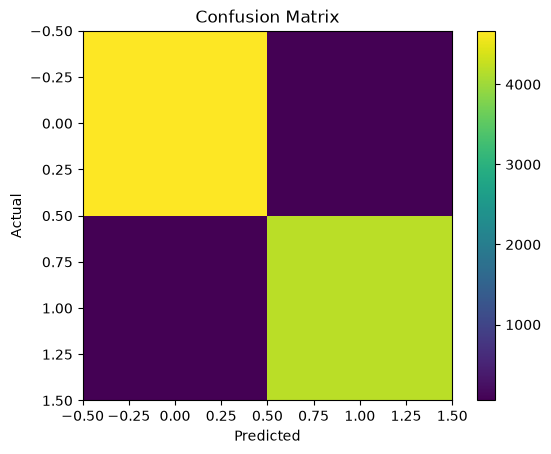

In [60]:
plt.imshow(cm)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [61]:
for name, model in models.items():

    prediction = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        prediction
    )

    print(name)

    print(cm)

KNN
[[4449  284]
 [1757 2490]]
Logistic Regression
[[4667   66]
 [  52 4195]]
Random Forest
[[4720   13]
 [  11 4236]]
Neural Network
[[4704   29]
 [  44 4203]]


In [62]:
news = ["Government announces a new education scheme for students"]

clean_news = [clean_text(news[0])]

news_vector = tfidf.transform(clean_news)

result = logreg.predict(news_vector)

if result[0] == 0:
    print("Fake News")
else:
    print("Real News")

Fake News


In [63]:
news = ["Cheif minister of karnataka is siddharayya"]

clean_news = [clean_text(news[0])]

news_vector = tfidf.transform(clean_news)

result = logreg.predict(news_vector)

if result[0] == 0:
    print("Fake News")
else:
    print("Real News")

Real News


In [65]:
import pickle

In [66]:
pickle.dump(
    logreg,
    open("model.pkl","wb")
)

In [67]:
pickle.dump(
    tfidf,
    open("tfidf.pkl","wb")
)

In [68]:
loaded_model = pickle.load(
open("model.pkl","rb")
)

In [69]:
loaded_tfidf = pickle.load(
open("tfidf.pkl","rb")
)

In [70]:
news = ["Government launches new education scheme"]

news = [clean_text(news[0])]

news = loaded_tfidf.transform(news)

prediction = loaded_model.predict(news)

print(prediction)

[0]
